In [4]:
import pandas as pd
import numpy as np

from umap import UMAP
from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv("./alkynes_dataset_mordred.csv", index_col=0)

In [6]:
from sklearn.preprocessing import scale

# standardize
df = pd.DataFrame(scale(df), index=df.index, columns=df.columns)

# drop zero-variance features
zero_std_cols = df.columns[df.std() == 0]
df = df[df.columns.difference(zero_std_cols)]

print(f"Dropping {len(zero_std_cols)} features {zero_std_cols}")

Dropping 225 features Index(['nSpiro', 'nBridgehead', 'nB', 'nS', 'nP', 'nI', 'nBondsT', 'Xch-3d',
       'Xch-4d', 'Xch-3dv',
       ...
       'nG12FARing', 'n4FAHRing', 'n5FAHRing', 'n6FAHRing', 'n7FAHRing',
       'n8FAHRing', 'n11FAHRing', 'n12FAHRing', 'nG12FAHRing', 'SRW03'],
      dtype='object', length=225)


In [7]:
# drop highly correlated features
df_corr = df.corr().abs()
upper = df_corr.where(np.triu(np.ones(df_corr.shape),k=1).astype(np.bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
df = df.drop(to_drop, axis=1)

print(f"Dropping {len(to_drop)} features {to_drop}")


Dropping 1013 features ['AATS0dv', 'AATS0m', 'AATS0p', 'AATS0pe', 'AATS0s', 'AATS0se', 'AATS0v', 'AATS1Z', 'AATS1are', 'AATS1d', 'AATS1dv', 'AATS1m', 'AATS1p', 'AATS1pe', 'AATS1s', 'AATS1se', 'AATS1v', 'AATS2Z', 'AATS2are', 'AATS2d', 'AATS2dv', 'AATS2i', 'AATS2m', 'AATS2p', 'AATS2pe', 'AATS2s', 'AATS2se', 'AATS2v', 'AATS3Z', 'AATS3are', 'AATS3d', 'AATS3dv', 'AATS3m', 'AATS3p', 'AATS3pe', 'AATS3s', 'AATS3se', 'AATS3v', 'AATS4Z', 'AATS4are', 'AATS4d', 'AATS4dv', 'AATS4m', 'AATS4p', 'AATS4pe', 'AATS4s', 'AATS4se', 'AATS4v', 'AATS5Z', 'AATS5are', 'AATS5dv', 'AATS5m', 'AATS5pe', 'AATS5s', 'AATS5se', 'AATS5v', 'AATSC0Z', 'AATSC0are', 'AATSC0dv', 'AATSC0i', 'AATSC0m', 'AATSC0p', 'AATSC0pe', 'AATSC0s', 'AATSC0se', 'AATSC0v', 'AATSC1c', 'AATSC1m', 'AATSC1p', 'AATSC1pe', 'AATSC1s', 'AATSC1se', 'AATSC1v', 'AATSC2are', 'AATSC2dv', 'AATSC2i', 'AATSC2m', 'AATSC2pe', 'AATSC2s', 'AATSC2se', 'AATSC2v', 'AATSC3m', 'AATSC3pe', 'AATSC3s', 'AATSC3se', 'AATSC3v', 'AATSC4m', 'AATSC4pe', 'AATSC4s', 'AATSC4se'

In [8]:
df

,AATS0Z,AATS0are,AATS0d,AATS0i,AATS1i,AATS3i,AATS4i,AATS5d,AATS5i,AATS5p,...,n6AHRing,n6ARing,n6HRing,n7AHRing,n7ARing,n9FHRing,nAHRing,nARing,nAcid,nBase
C#CC(=O)C(C)C,-0.557658,-0.659634,-1.378801,0.062653,-0.363022,0.369710,1.401843,-2.303625,-0.791575,-0.578168,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
C#CC(=O)C(OCC)OCC,-0.464718,0.021847,-1.219690,0.564180,0.603186,1.779276,-0.506929,-0.249308,0.023851,-0.382812,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
C#CC(=O)CC,-0.488383,-0.408535,-1.574848,-0.094323,-0.409651,1.349820,0.175265,-2.303625,-0.016917,-1.197244,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
C#CC(=O)CCC,-0.557658,-0.659634,-1.640197,0.062653,-0.363022,1.346827,0.536838,-1.477870,0.040340,-0.754098,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
C#CC(=O)CCc1ccccc1,-0.465892,-0.687275,-0.297572,-0.889788,-1.416873,-0.313096,-0.589580,0.392222,-0.456537,0.034720,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OCCC#Cc1ccccn1,-0.426178,-0.358580,-0.431240,-0.198848,0.063220,0.791501,-0.861555,1.825149,-1.018853,1.170848,...,-0.18628,-0.249696,1.668466,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
OCCC#Cc1cccnc1,-0.426178,-0.358580,-0.431240,-0.198848,0.063220,0.429767,-0.680415,1.825149,-1.561180,1.346721,...,-0.18628,-0.249696,1.668466,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
OCCC#Cc1ccncc1,-0.426178,-0.358580,-0.431240,-0.198848,0.063220,0.466050,-1.147649,1.607845,-1.357590,1.115079,...,-0.18628,-0.249696,1.668466,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919
OCc1ccc(C#CC(F)(F)F)cc1,-0.010734,2.203730,0.992435,2.108539,0.906857,-0.548056,-0.235039,1.454984,0.604694,-0.366557,...,-0.18628,-0.249696,-0.562959,-0.047873,-0.061851,-0.235607,-0.242731,-0.325944,-0.073239,-0.208919


In [9]:
# ===================== 5. UMAP =====================
dims = [50, 20, 15, 10, 5, 2]

dfs = {}

# UMAP section
n_neigh = np.int_(np.sqrt(df.shape[1]))
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(
        n_components=dim, n_neighbors=n_neigh,random_state=0
    ).fit_transform(df), index=df.index)

# PCA section
pc = pd.DataFrame(PCA(n_components=None).fit_transform(df), index=df.index)
for dim in dims:
    key = f"pc{dim}"
    dfs[key] = pc.iloc[:, :dim]

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/minico

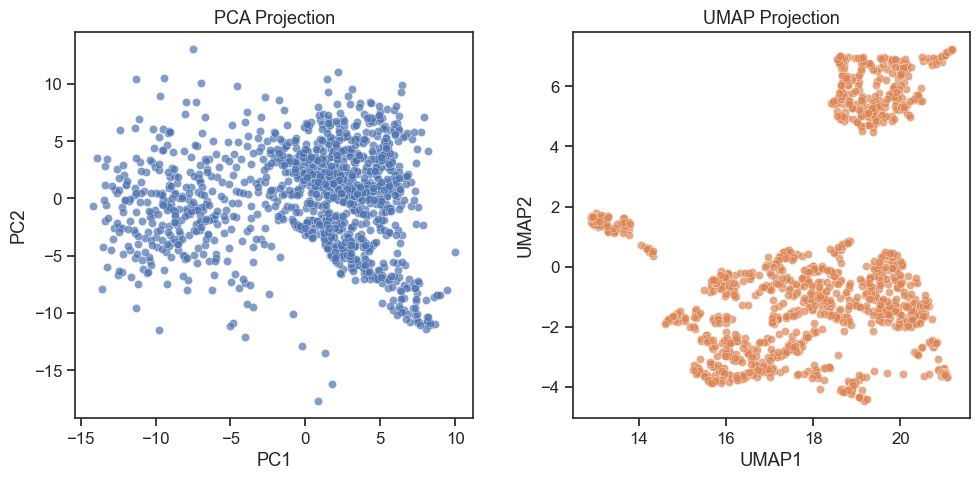

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2

# =========================
# Data
# =========================
dfs['pc2'].columns = ['PC1', 'PC2']
dfs['umap2'].columns = ['UMAP1', 'UMAP2']

# =========================
# Figure
# =========================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# PCA
sns.scatterplot(
    data=dfs['pc2'],
    x='PC1',
    y='PC2',
    s=35,
    alpha=0.7,
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[0]
)

ax[0].set_title("PCA Projection", fontsize=13)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# UMAP
sns.scatterplot(
    data=dfs['umap2'],
    x='UMAP1',
    y='UMAP2',
    s=35,
    alpha=0.7,
    color='#DD8452',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[1]
)

ax[1].set_title("UMAP Projection", fontsize=13)
ax[1].set_xlabel("UMAP1")
ax[1].set_ylabel("UMAP2")

# =========================
# Style polishing
# =========================

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
fig.savefig("../fig/mordred_1.svg", dpi=330)
fig.savefig("../fig/mordred_1.pdf", dpi=330)
plt.show()

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, fclusterdata
from sklearn.metrics import silhouette_score

# Define the numbeor of clusters to study
N_CLS_list = list(range(5, 41))
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical cluster ing using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

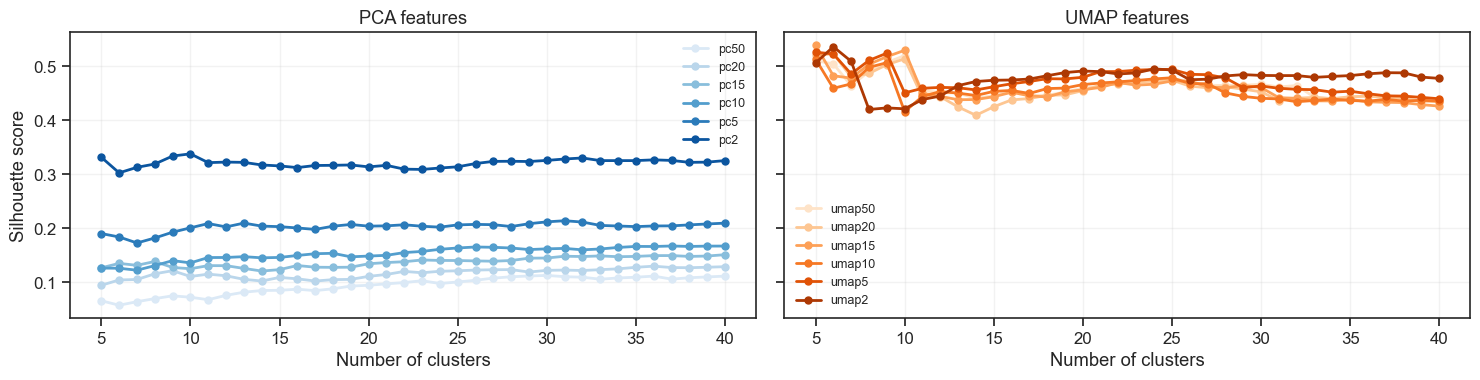

In [12]:
silh_scores = pd.DataFrame(index=N_CLS_list)

for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)

# 分组
pca_cols = silh_scores.columns[silh_scores.columns.str.startswith("pc")]
umap_cols = silh_scores.columns[silh_scores.columns.str.startswith("umap")]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

pca_palette = sns.color_palette("Blues", len(pca_cols))
umap_palette = sns.color_palette("Oranges", len(umap_cols))

# PCA
for i, col in enumerate(pca_cols):
    ax[0].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=pca_palette[i],
        label=col
    )

ax[0].set_title("PCA features")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Silhouette score")
ax[0].legend(frameon=False, fontsize=9)

# UMAP
for i, col in enumerate(umap_cols):
    ax[1].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=umap_palette[i],
        label=col
    )

ax[1].set_title("UMAP features")
ax[1].set_xlabel("Number of clusters")
ax[1].legend(frameon=False, fontsize=9)

# Style
for a in ax:
    a.grid(alpha=0.25)

plt.tight_layout()
fig.savefig("../fig/mordred_2.svg", dpi=330)
fig.savefig("../fig/mordred_2.pdf", dpi=330)
plt.show()